# 05. AutoEncoder — 정답 없이 배우기

지금까지(01~04)는 전부 **분류**였다. 이미지를 넣으면 "이건 6", "이건 고양이"처럼
**정답(label)을 맞히는** 문제. 이런 걸 **지도학습(supervised learning)** 이라 한다.

이 노트북은 다르다. **AutoEncoder(오토인코더)** 는 정답을 주지 않는다.
대신 이미지를 넣고 **"그 이미지를 그대로 다시 만들어내라"** 고 시킨다.

```
입력 이미지  →  [압축]  →  작은 벡터  →  [복원]  →  출력 이미지
   28×28         인코더      (예: 288개)    디코더      28×28
                              ↑ 정보 병목
        목표: 출력이 입력과 최대한 똑같아지도록
```

**왜 이런 걸 할까?** 입력을 좁은 병목(bottleneck)으로 억지로 통과시키면,
모델은 이미지의 **핵심 특징만 남기고 압축하는 법**을 스스로 배운다.
정답 레이블이 필요 없으니 **비지도학습(unsupervised learning)** 이다.

이 노트북에서 다루는 것:
1. **인코더 / 디코더 / 잠재벡터** 구조
2. **Dense 디코더 vs Conv 디코더** — 같은 일을 하는데 파라미터가 40배 차이
3. (2부) **2차원까지 압축** — 잠재공간을 눈으로 그려보기


## 준비 — MNIST 불러오기

AutoEncoder의 입력과 정답이 **모두 이미지 자기 자신**이다. 그래서 레이블(y)은 쓰지 않는다.
CNN 인코더를 쓸 것이므로 채널 축을 붙여 `(N, 28, 28, 1)` 형태로 만든다.


In [1]:
from tensorflow.keras.datasets import mnist
import numpy as np

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 채널 축 추가 + 스케일링. y(레이블)는 AutoEncoder 학습엔 안 쓴다.
x_train_nm = x_train[:, :, :, np.newaxis] / 255
x_test_nm = x_test[:, :, :, np.newaxis] / 255
print("입력 shape:", x_train_nm.shape)   # (60000, 28, 28, 1)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
입력 shape: (60000, 28, 28, 1)


## 1부. 인코더 만들기 — 이미지를 288개 숫자로 압축

AutoEncoder는 두 부분으로 나뉜다. 먼저 **인코더(encoder)**.

인코더는 노트북 03의 CNN과 똑같은 구조다 — Conv/Pooling으로 이미지를 점점 작게 만든다.
다만 **분류용 Dense(10) 출력층이 없다.** 마지막 Flatten까지만 한다.

```
Input(28,28,1)
  → Conv2D(32,5×5) → MaxPool   # 28 → 14
  → Conv2D(32,5×5) → MaxPool   # 14 → 7
  → Conv2D(32,5×5) → MaxPool   # 7 → 3
  → Flatten                     # 3×3×32 = 288
```

결과는 **288개의 숫자** — 이게 **잠재벡터(latent vector)** 다.
28×28=784개 픽셀이 288개로 압축됐다. 이 288개 안에 숫자의 핵심 정보가 담긴다.


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten

encoder = Sequential(name='encoder')
encoder.add(Input(shape=(28, 28, 1)))
encoder.add(Conv2D(32, (5, 5), padding='same', activation='relu'))
encoder.add(MaxPooling2D((2, 2)))
encoder.add(Conv2D(32, (5, 5), padding='same', activation='relu'))
encoder.add(MaxPooling2D((2, 2)))
encoder.add(Conv2D(32, (5, 5), padding='same', activation='relu'))
encoder.add(MaxPooling2D((2, 2)))
encoder.add(Flatten())
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,096 (203.50 KB)

 Trainable params: 52,096 (203.50 KB)

 Non-trainable params: 0 (0.00 B)

## 디코더 만들기 (버전 1) — Dense로 복원

**디코더(decoder)** 는 인코더의 반대다. 288개 잠재벡터를 받아 **다시 784(=28×28) 픽셀로 펼친다.**

첫 번째 버전은 **Dense 층만으로** 복원한다:

```
Input(288) → Dense(784) → Dense(3136) → Dense(784, sigmoid) → Reshape(28,28,1)
```

- 마지막 활성화가 **`sigmoid`** 인 이유: 픽셀 값을 **0~1 사이**로 만들어야 한다
  (입력을 `/255`로 0~1로 만들었으니 출력도 같은 범위여야 비교가 된다).
- **주목: 이 Dense 디코더는 파라미터가 매우 많다** (약 510만 개).
  단순히 숫자를 펼치는 데 이렇게 많은 가중치를 쓴다. 2부에서 Conv 디코더와 비교하면 이 낭비가 드러난다.


In [3]:
from tensorflow.keras.layers import Dense, Reshape

decoder = Sequential(name='decoder')
decoder.add(Input(shape=(288,)))
decoder.add(Dense(784, activation='relu'))
decoder.add(Dense(3136, activation='relu'))
decoder.add(Dense(784, activation='sigmoid'))
decoder.add(Reshape((28, 28, 1)))
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 784)            │       226,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │     2,461,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │     2,459,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,147,744 (19.64 MB)

 Trainable params: 5,147,744 (19.64 MB)

 Non-trainable params: 0 (0.00 B)

## 인코더 + 디코더 = AutoEncoder

두 모델을 연결한다. 입력이 인코더를 거쳐 288개로 압축됐다가, 디코더를 거쳐 다시 28×28로 복원된다.

**핵심: 정답(y)이 없다.** `fit(x, x)` — 입력과 정답이 **둘 다 x**다.
"이 이미지를 넣으면 이 이미지가 나오게 하라"고 학습시킨다.

- 손실: **`binary_crossentropy`** — 픽셀 하나하나를 0~1 확률처럼 보고, 입력과 출력의 차이를 잰다.
  (`mse`를 써도 되지만, 0~1 픽셀엔 BCE가 흔히 쓰인다.)
- 정확도(accuracy)는 의미가 없다 — 분류가 아니니까. loss만 본다.


In [4]:
from tensorflow.keras.models import Model

inp = Input(shape=(28, 28, 1))
latent = encoder(inp)
output = decoder(latent)
autoencoder = Model(inp, output)
autoencoder.summary()

autoencoder.compile(loss='binary_crossentropy', optimizer='adam')


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Sequential)            │ (None, 288)            │        52,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 28, 28, 1)      │     5,147,744 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,199,840 (19.84 MB)

 Trainable params: 5,199,840 (19.84 MB)

 Non-trainable params: 0 (0.00 B)

## 학습

`fit(x_train_nm, x_train_nm, ...)` — 입력도 정답도 같은 이미지.

> ⚠️ CPU에서는 에폭당 수 분 걸린다. **GPU 런타임**을 켜는 게 좋다.
> 원본 수업에서는 이 학습이 오래 걸려서 중간에 멈추기도 했다. 에폭을 5로 줄여도 경향은 보인다.


In [5]:
hist = autoencoder.fit(x_train_nm, x_train_nm,
                       validation_data=(x_test_nm, x_test_nm),
                       epochs=5)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 0.1161 - val_loss: 0.0863
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0830 - val_loss: 0.0790
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0781 - val_loss: 0.0768
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0755 - val_loss: 0.0746
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0738 - val_loss: 0.0737


## 복원 결과 확인 — 원본 vs 재구성

테스트 이미지를 넣어서, 원본과 AutoEncoder가 복원한 이미지를 나란히 본다.
잘 학습됐다면 복원 이미지가 원본과 거의 같아야 한다 (약간 흐릿할 수 있다).


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 926ms/step


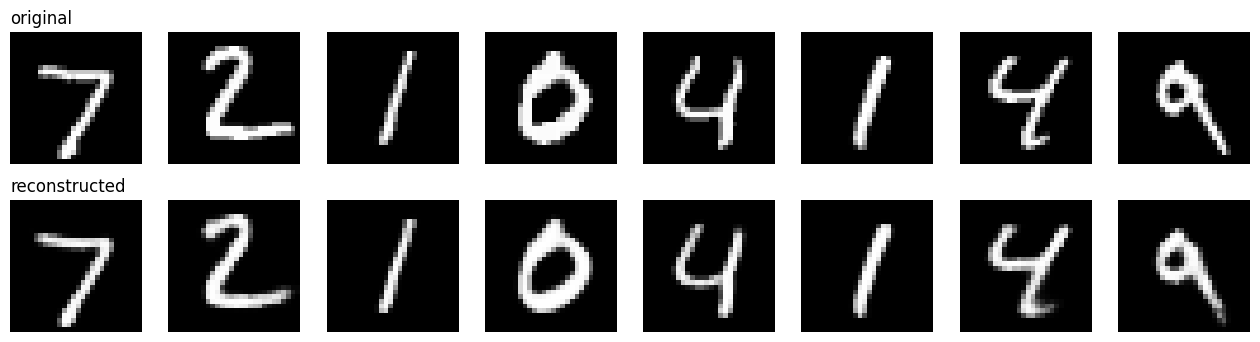

In [6]:
import matplotlib.pyplot as plt

n = 8   # 8장 비교
recon = autoencoder.predict(x_test_nm[:n])

fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
for i in range(n):
    axes[0, i].imshow(x_test_nm[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_title('original', loc='left')
axes[1, 0].set_title('reconstructed', loc='left')
plt.show()


---
## 2부. Conv 디코더 — 40배 가볍게

1부의 Dense 디코더는 **520만 파라미터**를 썼다. 대부분 낭비다 —
숫자를 그냥 펼치는 데 거대한 완전연결층 3개를 쌓았기 때문이다.

**Conv 디코더**는 인코더를 거꾸로 뒤집는다. 인코더가 Conv+Pooling으로 **줄였으니**,
디코더는 **UpSampling(키우기)+Conv**로 **되돌린다.**

```
Input(288) → Reshape(3,3,32)
  → UpSampling(2×2) → Resizing(7,7)          # 3 → 6 → 7
  → Conv2D(32,5×5, relu)
  → UpSampling(2×2)                           # 7 → 14
  → Conv2D(32,5×5, relu)
  → UpSampling(2×2)                           # 14 → 28
  → Conv2D(32,5×5, relu)
  → Conv2D(1, 3×3, sigmoid)                   # 채널 1개로 (28,28,1)
```

**`Resizing(7,7)`가 왜 필요한가? ★**
인코더에서 7 → 3으로 줄일 때, MaxPooling은 7÷2를 **내림해서 3**으로 만든다.
그래서 디코더에서 3을 2배 키우면 6이 되는데, **7이 필요하다.** 이 1칸 차이를 `Resizing(7,7)`이 메꾼다.
(딥러닝에서 자주 만나는 **홀수 크기 풀링의 함정**이다.)


In [7]:
from tensorflow.keras.layers import Reshape, UpSampling2D, Resizing, Conv2D

decoder2 = Sequential(name='conv_decoder')
decoder2.add(Input(shape=(288,)))
decoder2.add(Reshape((3, 3, 32)))
decoder2.add(UpSampling2D((2, 2)))          # 3 → 6
decoder2.add(Resizing(7, 7))                # 6 → 7 (홀수 풀링 보정)
decoder2.add(Conv2D(32, (5, 5), padding='same', activation='relu'))
decoder2.add(UpSampling2D((2, 2)))          # 7 → 14
decoder2.add(Conv2D(32, (5, 5), padding='same', activation='relu'))
decoder2.add(UpSampling2D((2, 2)))          # 14 → 28
decoder2.add(Conv2D(32, (5, 5), padding='same', activation='relu'))
decoder2.add(Conv2D(1, (3, 3), padding='same', activation='sigmoid'))
decoder2.summary()


Model: "conv_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 32)       │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,185 (301.50 KB)

 Trainable params: 77,185 (301.50 KB)

 Non-trainable params: 0 (0.00 B)

### Conv 디코더로 다시 학습

인코더는 1부 것을 **그대로 재사용**한다 (이미 학습된 상태). 디코더만 새 것으로 연결한다.


In [8]:
inp2 = Input(shape=(28, 28, 1))
autoencoder2 = Model(inp2, decoder2(encoder(inp2)))
autoencoder2.summary()

autoencoder2.compile(loss='binary_crossentropy', optimizer='adam')

hist2 = autoencoder2.fit(x_train_nm, x_train_nm,
                         validation_data=(x_test_nm, x_test_nm),
                         epochs=5)


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Sequential)            │ (None, 288)            │        52,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_decoder (Sequential)       │ (None, 28, 28, 1)      │        77,185 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,281 (505.00 KB)

 Trainable params: 129,281 (505.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 0.0930 - val_loss: 0.0748
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0739 - val_loss: 0.0715
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0714 - val_loss: 0.0717
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0701 - val_loss: 0.0696
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0691 - val_loss: 0.0684


### Dense vs Conv 디코더 비교 ★

두 디코더의 파라미터와 성능을 나란히 놓는다. 실제 숫자로 표를 채워보자.

| | Dense 디코더 (1부) | Conv 디코더 (2부) |
|---|---|---|
| 디코더 파라미터 | 5,147,744 | *(셀 위 결과)* |
| 최종 val_loss | 0.0737 | *(위 학습 결과)* |

**같은 복원 품질을 훨씬 적은 파라미터로** — 이게 Conv 디코더의 핵심이다.
Conv는 필터를 이미지 전체에 재사용하므로, 위치마다 가중치를 따로 두는 Dense보다 압도적으로 효율적이다.
(노트북 03에서 배운 CNN의 강점이 디코더에서도 그대로 나타난다.)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step


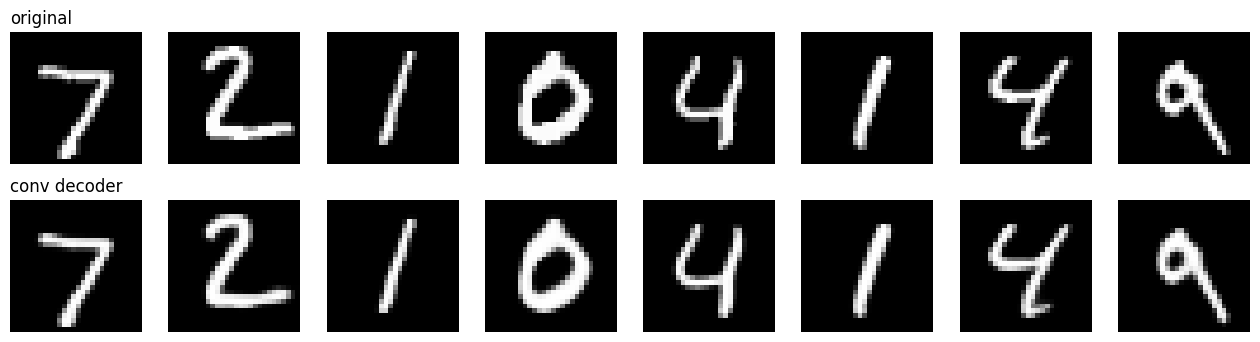

In [9]:
recon2 = autoencoder2.predict(x_test_nm[:8])

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(x_test_nm[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(recon2[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_title('original', loc='left')
axes[1, 0].set_title('conv decoder', loc='left')
plt.show()


---
## 3부. 잠재공간을 눈으로 보기 — 2차원까지 압축

지금까지 잠재벡터는 288차원이었다. 복원은 잘 되지만, **288개 숫자는 그림으로 그릴 수 없다.**

이번엔 극단적으로 **2차원까지** 압축한다. 병목을 `Dense(2)`로 좁힌다.
2개 숫자면 **평면 위의 점 하나**다 — 즉 **모든 이미지를 2D 지도 위에 찍을 수 있다.**

당연히 복원 품질은 나빠진다 (784 → 2는 엄청난 압축). 하지만 목표가 다르다:
**"AutoEncoder가 숫자들을 잠재공간에 어떻게 배치하는가"** 를 보는 것이다.

새 인코더 구조 (필터를 32→16→8로 줄이고, 마지막에 Dense(2) 병목 추가):
```
Input(28,28,1)
  → Conv(32) → Pool → Conv(16) → Pool → Conv(8) → Pool
  → Flatten → Dense(2)     ← 2차원 잠재벡터
```


In [10]:
from tensorflow.keras.layers import Dense

# 2차원 병목 인코더
encoder2d = Sequential(name='encoder_2d')
encoder2d.add(Input(shape=(28, 28, 1)))
encoder2d.add(Conv2D(32, (5, 5), padding='same', activation='relu'))
encoder2d.add(MaxPooling2D((2, 2)))
encoder2d.add(Conv2D(16, (5, 5), padding='same', activation='relu'))
encoder2d.add(MaxPooling2D((2, 2)))
encoder2d.add(Conv2D(8, (5, 5), padding='same', activation='relu'))
encoder2d.add(MaxPooling2D((2, 2)))
encoder2d.add(Flatten())
encoder2d.add(Dense(2))              # ← 2차원으로 압축
encoder2d.summary()


Model: "encoder_2d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 16)     │        12,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 8)        │         3,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 72)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           146 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,002 (66.41 KB)

 Trainable params: 17,002 (66.41 KB)

 Non-trainable params: 0 (0.00 B)

### 2차원용 디코더와 학습

디코더는 2 → 다시 28×28로 키운다. 시작 차원만 2로 바뀌고 나머지는 2부 Conv 디코더와 같은 원리다.


In [11]:
decoder2d = Sequential(name='decoder_2d')
decoder2d.add(Input(shape=(2,)))
decoder2d.add(Dense(3 * 3 * 8, activation='relu'))
decoder2d.add(Reshape((3, 3, 8)))
decoder2d.add(UpSampling2D((2, 2)))        # 3 → 6
decoder2d.add(Resizing(7, 7))              # 6 → 7
decoder2d.add(Conv2D(8, (5, 5), padding='same', activation='relu'))
decoder2d.add(UpSampling2D((2, 2)))        # 7 → 14
decoder2d.add(Conv2D(16, (5, 5), padding='same', activation='relu'))
decoder2d.add(UpSampling2D((2, 2)))        # 14 → 28
decoder2d.add(Conv2D(32, (5, 5), padding='same', activation='relu'))
decoder2d.add(Conv2D(1, (3, 3), padding='same', activation='sigmoid'))

inp2d = Input(shape=(28, 28, 1))
ae2d = Model(inp2d, decoder2d(encoder2d(inp2d)))
ae2d.compile(loss='binary_crossentropy', optimizer='adam')

hist2d = ae2d.fit(x_train_nm, x_train_nm,
                  validation_data=(x_test_nm, x_test_nm),
                  epochs=10)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 0.2201 - val_loss: 0.2043
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1989 - val_loss: 0.1948
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1931 - val_loss: 0.1906
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1896 - val_loss: 0.1891
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1874 - val_loss: 0.1856
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.1857 - val_loss: 0.1859
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1845 - val_loss: 0.1845
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1835 - val_loss: 0.1837
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.1827 - val_loss: 0.1840
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1822 - val_loss: 0.1817


### 잠재공간 지도 ★ — 이 노트북의 백미

테스트 이미지 몇백 장을 인코더에 넣어, 각 이미지가 **2D 평면 어디에 찍히는지** 그린다.
그리고 **각 점을 실제 숫자 레이블로 색칠한다.**

**핵심: 학습할 때 레이블(y)을 단 한 번도 쓰지 않았다.** `fit(x, x)` 뿐이었다.
그런데도 같은 숫자끼리 뭉쳐서 군집을 이룬다면 — AutoEncoder가 **스스로 "숫자의 생김새"를
이해하고 비슷한 것끼리 가까이 배치했다**는 뜻이다. 이게 비지도학습의 힘이다.


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


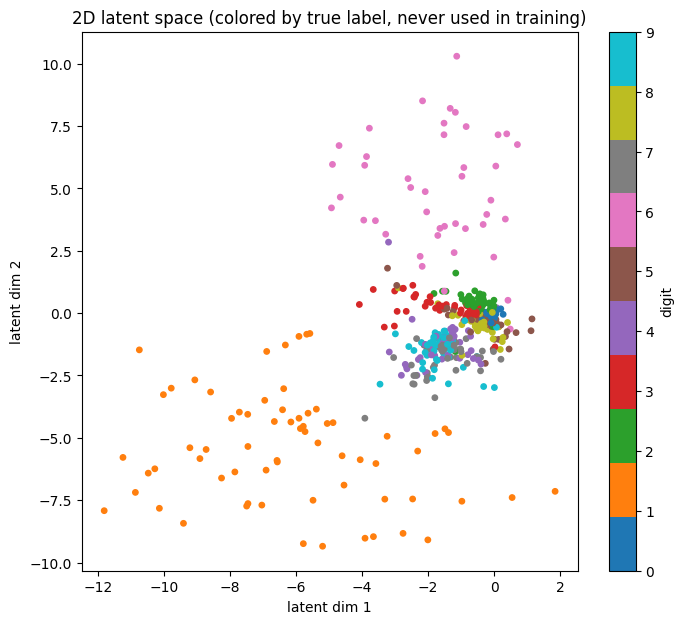

In [12]:
# 테스트 500장을 2D 잠재공간에 투영
latent_2d = encoder2d.predict(x_test_nm[:500])

plt.figure(figsize=(8, 7))
sc = plt.scatter(latent_2d[:, 0], latent_2d[:, 1],
                 c=y_test[:500], cmap='tab10', s=15)
plt.colorbar(sc, label='digit')
plt.xlabel('latent dim 1')
plt.ylabel('latent dim 2')
plt.title('2D latent space (colored by true label, never used in training)')
plt.show()


### 디코더는 생성기(generator)다 — 빈 공간에서 숫자 만들어내기

인코더 없이 **디코더만** 쓰면, 잠재공간의 **임의의 좌표**를 넣어 숫자를 만들어낼 수 있다.
학습 데이터에 없던 새 이미지를 **생성**하는 것이다. (VAE·GAN 같은 생성모델의 출발점이다.)

위 산점도에서 점들이 모여 있는 영역의 좌표를 골라 디코더에 넣어보자.


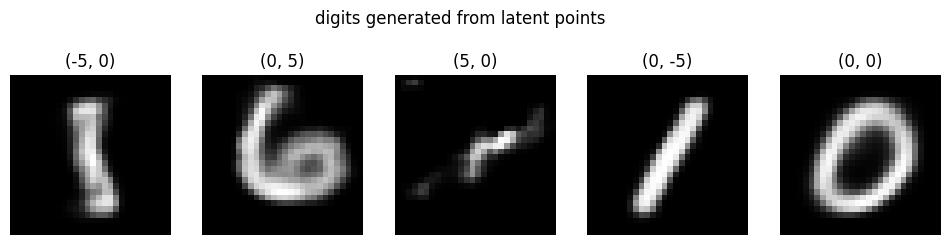

In [13]:
# 잠재공간의 여러 좌표에서 숫자 생성 (좌표는 위 산점도 범위를 보고 조정)
import numpy as np

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
points = [(-5, 0), (0, 5), (5, 0), (0, -5), (0, 0)]
for ax, (a, b) in zip(axes, points):
    gen = decoder2d.predict(np.array([[a, b]]), verbose=0)
    ax.imshow(gen[0].reshape(28, 28), cmap='gray')
    ax.set_title(f'({a}, {b})')
    ax.axis('off')
plt.suptitle('digits generated from latent points')
plt.show()


### 무슨 일이 일어났는가 ★ — 이 노트북의 결론

**잠재공간 지도 (셀 위 산점도):**
`Dense(2)`로 압축한 2차원 평면에 테스트 숫자 500장을 찍고, 실제 레이블로 색칠했다.
결과를 보면 — **레이블을 학습에 한 번도 안 썼는데(`fit(x, x)`뿐), 같은 숫자끼리 뭉쳐 있다:**

- **1(주황)** 은 왼쪽 아래에 완전히 따로 떨어진 큰 군집 — 얇고 곧은 형태라 가장 확실히 구분된다.
- **6(분홍)** 은 위쪽에, **2(초록)·3(빨강)** 도 각자 영역을 차지한다.
- 반면 0·4·7·8·9 는 중앙에 겹쳐 있다 — **2차원으론 10개를 다 분리하기엔 너무 좁기** 때문이다.
  (그래서 복원 손실도 0.18로 높았다.)

이게 **비지도학습의 힘**이다. AutoEncoder는 "이건 1, 이건 6"이라고 배운 적이 없다.
그저 "입력을 잘 복원하라"는 목표만으로, **비슷하게 생긴 숫자를 잠재공간에서 가까이 배치하는 법**을
스스로 터득했다. 압축을 잘하려면 비슷한 것끼리 모아야 하니까.

**디코더 = 생성기 (셀 위 생성 이미지):**
인코더 없이 디코더만으로, 잠재공간의 좌표를 직접 넣어 숫자를 만들어냈다.
놀랍게도 **좌표가 산점도 위치와 일치한다** — 위쪽 `(0, 5)`에서는 **6**이, 아래쪽 `(0, -5)`에서는 **1**이,
중앙 `(0, 0)`에서는 **0**이 생성됐다. 산점도에서 6이 위, 1이 아래였던 것과 정확히 맞아떨어진다.

이건 학습 데이터에 없던 이미지를 **새로 생성**한 것이다.
잠재공간을 부드럽게 이동하면 숫자가 서서히 변형된다 — **VAE·GAN 같은 생성모델의 핵심 아이디어**가
여기서 싹튼다.

> 참고: `Dense(2)`에 활성화가 없어서 잠재값 범위는 실행마다 다르다.
> 위 생성 좌표는 이번 산점도 범위(x: -12~2, y: -10~10)에 맞춘 것이니,
> 다시 학습하면 산점도를 보고 좌표를 조정해야 한다.

---

## 정리 — AutoEncoder

| 개념 | 핵심 |
|---|---|
| **비지도학습** | 정답 없이 `fit(x, x)`. 입력을 스스로 압축·복원하며 특징을 배운다 |
| **인코더 / 디코더** | 인코더는 압축(→잠재벡터), 디코더는 복원. 디코더는 인코더의 역방향 |
| **잠재벡터(latent)** | 병목을 통과한 압축 표현. 288차원이면 복원 잘됨, 2차원이면 시각화 가능 |
| **Dense vs Conv 디코더** | Conv가 1/67 파라미터로 더 나은 복원 (필터 재사용, 노트북 03의 교훈) |
| **잠재공간의 구조** | 레이블 없이도 숫자별로 군집이 생긴다 (비지도학습의 힘) |
| **디코더 = 생성기** | 잠재 좌표를 넣어 새 이미지를 만든다 (VAE·GAN의 출발점) |

**다음 노트북(06)** 에서는 지금까지의 이미지(공간 데이터)를 떠나,
**순서가 있는 데이터(시퀀스)** 를 다루는 **RNN**을 본다.
글자를 하나씩 예측하고, 문장의 감정을 분류하고, 이미지마저 "위에서 아래로 읽는 순서"로 처리해본다.